In [1]:
import numpy as np
from PIL import Image
import taichi as ti
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization, resample_polyline, get_area

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


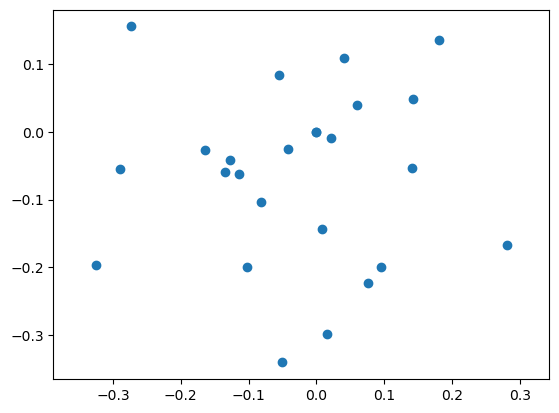

In [11]:
def init_trajectory(control_point_num):  # 生成初始轨迹
    xs, ys, rotations = resample_polyline([
        [0, 0, 0],
        [0, 0, 2 * np.pi]
    ], control_point_num).T
    return xs, ys, rotations

xs, ys, rotations = init_trajectory(  # 初始轨迹
    control_point_num=25,  # 轨迹的控制点数量
)

xs[1:-1] += np.random.randn(len(xs) - 2) * 0.15
ys[1:-1] += np.random.randn(len(ys) - 2) * 0.15

plt.scatter(xs, ys)
plt.axis('equal')
pass

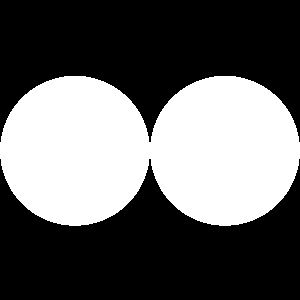

In [12]:
# 可视化墙（白色区域为墙）

from utils import test_forbidden_function

center_0 = ti.Vector([0.5, 0])
center_1 = ti.Vector([-0.5, 0.])
r = 0.5
@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    v = ti.Vector([x2, y2])
    return (v - center_0).norm() < r or (v - center_1).norm() < r

image = test_forbidden_function(
    is_forbidden,
    -1, 1, -1, 1, [300, 300],
    # wall_normal=[0, 0.05]
)
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [24]:
xs, ys, rotations = np.load('../trajectory/能让两个圆旋转一周的房间_r0.5_1/sofa_299.npy')

In [ ]:
# delta_x = xs[0] - (xs[1] + xs[-2]) / 2
# delta_y = ys[0] - (ys[1] + ys[-2]) / 2
# xs[1:-1] += delta_x
# ys[1:-1] += delta_y

(-0.12685112937140738,
 0.12643788720351637,
 -0.3340617163466646,
 0.34860359117812734)

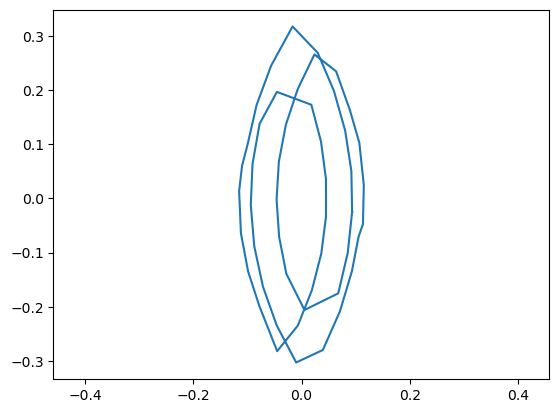

In [27]:
plt.plot(xs, ys)
plt.axis('equal')

Initial survivors: 5.936814308166504
iter 500 / 10100, maximal_area=5.936960220336914
iter 1000 / 10100, maximal_area=5.937114715576172
iter 1500 / 10100, maximal_area=5.937252044677734
iter 2000 / 10100, maximal_area=5.937337875366211
iter 2500 / 10100, maximal_area=5.937363624572754
iter 3000 / 10100, maximal_area=5.937440872192383
iter 3500 / 10100, maximal_area=5.937518119812012
iter 4000 / 10100, maximal_area=5.937638282775879
iter 4500 / 10100, maximal_area=5.9376983642578125
iter 5000 / 10100, maximal_area=5.937784194946289
iter 5500 / 10100, maximal_area=5.937921524047852
iter 6000 / 10100, maximal_area=5.937938690185547
iter 6500 / 10100, maximal_area=5.9379730224609375
iter 7000 / 10100, maximal_area=5.9379730224609375
iter 7500 / 10100, maximal_area=5.9379987716674805
iter 8000 / 10100, maximal_area=5.938015937805176
iter 8500 / 10100, maximal_area=5.938033103942871
iter 9000 / 10100, maximal_area=5.938041687011719
iter 9500 / 10100, maximal_area=5.938041687011719
iter 10000

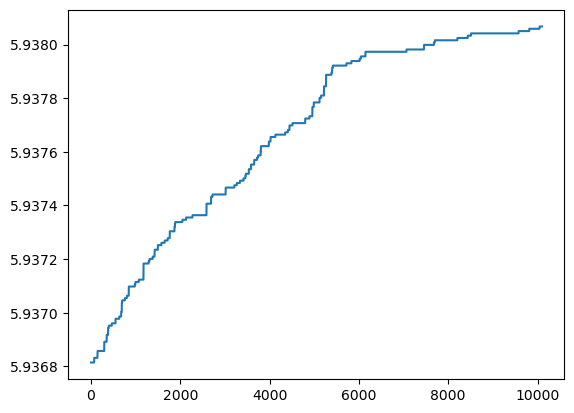

In [25]:
sofa_w, sofa_h = 3, 3   # 求解域的尺寸

best_score, xs, ys, rotations, sofa, maximal_area_record = run_optimization(
    is_forbidden,
    xs,  # 上采样使得轨迹分辨率翻倍时注释掉这三行
    ys,
    rotations,
    # initial_xs=zoom(xs, zoom=2, order=1),  # 保持轨迹分辨率时注释掉这三行
    # initial_ys=zoom(ys, zoom=2, order=1),
    # initial_rotations=zoom(rotations, zoom=2, order=1),
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    mutation_sigma_pos = 0.002,  # 变异率 0.002
    mutation_sigma_rotation = 0,  # 变异率 0.004
    iterations = 10100,  # 200000
    trajectory_upsampling=41,  # 41 101
    resolution=1024,  # 1024 2000
    print_every=500,  # 1000
    save_image_every=100,
    save_image_path='../images/能让两个圆旋转一周的房间_r0.5_1/sofa_',
    save_image_start_id=299,
    save_trajectory_path='../trajectory/能让两个圆旋转一周的房间_r0.5_1/sofa_',
    boundary_conditions='periodic'
)
print(f"Estimated maximal sofa area (by sampling): {best_score:.5f}")
# save mask image as PNG if pillow is available

img = (sofa * 255).astype(np.uint8)
im = Image.fromarray(img.T[::-1])
im.save('../sofa_survivors.png')
plt.plot(maximal_area_record)

In [26]:
area = sofa_w * sofa_h - maximal_area_record[-1]
area_compare = np.pi * ((0.5 + r) ** 2 - max(0, 0.5 - r) ** 2)
f'{area} / {area_compare} = {area / area_compare}'

'3.0619325637817383 / 3.141592653589793 = 0.9746434058798075'